In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import os
import seaborn as sns
import json
import tifffile as tiff
from skimage import measure
from shapely.geometry import Polygon
import statsmodels.formula.api as smf
import geopandas as gpd
from skimage import morphology
from scipy.stats import ttest_ind

In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [38]:
area_dict = {}

for img in adata.obs['image_ID'].unique():
    name = img.replace('.csv', '_bone_masks.tiff')
    mask = tiff.imread(os.path.join('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/bone_masks_corrected/', name))
    binary_mask = (mask == 255).astype(np.uint8)
    contours = measure.find_contours(binary_mask, 0.5)
    polygon_list = []
    for contour in contours:
        polygon_verts = contour[:, [1, 0]]
        polygon_list.append(Polygon(polygon_verts))
    areas = [polygon.area for polygon in polygon_list]
    total_area = np.sum(areas)
    area_dict[img] = total_area

In [46]:
df_bone_area = pd.DataFrame.from_dict(area_dict, orient='index', columns=['bone_area'])

In [47]:
disease_mapping = adata.obs[['disease2', 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)
patient_mapping = adata.obs[['patient_ID', 'image_ID']].drop_duplicates()
patient_mapping.set_index('image_ID', inplace=True)

In [48]:
df_bone_area['disease2'] = df_bone_area.index.map(disease_mapping['disease2'])
df_bone_area['patient_ID'] = df_bone_area.index.map(patient_mapping['patient_ID'])

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/1999010094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bone_area, x='disease2', y='bone_area', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/1999010094.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)


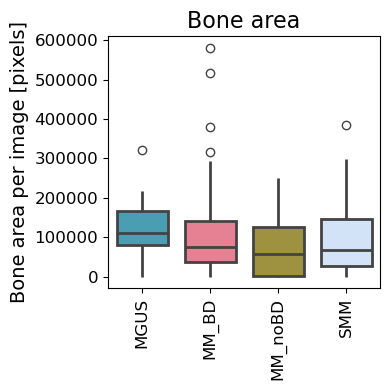

In [49]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=df_bone_area, x='disease2', y='bone_area', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
plt.xticks(rotation=90)
plt.title(f'Bone area', fontsize=16)
plt.ylabel('Bone area per image [pixels]', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'bone_area.{extension}'), bbox_inches='tight')

In [44]:
df_bone_area

,bone_area,disease2,patient_ID
TS-373_IMC77_B_001.csv,68621.50,MM_BD,IMC77
TS-373_IMC03_MGUS_002.csv,217837.75,MGUS,IMC03
TS-373_IMC04_MGUS_002.csv,72397.25,MGUS,IMC04
TS-373_IMC72_MGUS_001.csv,0.00,MGUS,IMC72
TS-373_IMC12_UB_001.csv,236137.00,MM_noBD,IMC12
...,...,...,...
TS-373_IMC41_MGUS_001.csv,0.00,SMM,IMC41
TS-373_IMC87-1_UB_001.csv,0.00,MM_noBD,IMC87-1
TS-373_IMC53_B_002.csv,38168.50,MM_BD,IMC53
TS-373_IMC47_B_002.csv,140392.25,MM_BD,IMC47


In [50]:
df_bone_area['disease2'] = pd.Categorical(df_bone_area['disease2'], categories=['MM_BD', 'MM_noBD', 'SMM', 'MGUS'], ordered=True)
model = smf.mixedlm("bone_area ~ disease2", data=df_bone_area, groups=df_bone_area['patient_ID'])
result = model.fit()
print(result.summary())

                   Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     bone_area      
No. Observations:       152         Method:                 REML           
No. Groups:             76          Scale:                  9932516891.8931
Min. group size:        1           Log-Likelihood:         -1919.6567     
Max. group size:        3           Converged:              Yes            
Mean group size:        2.0                                                
---------------------------------------------------------------------------
                      Coef.     Std.Err.   z    P>|z|   [0.025     0.975]  
---------------------------------------------------------------------------
Intercept           101147.098  9502.400 10.644 0.000  82522.736 119771.460
disease2[T.MM_noBD] -20683.835 24226.462 -0.854 0.393 -68166.828  26799.158
disease2[T.SMM]      11255.007 30716.744  0.366 0.714 -48948.706  71458.719
disease2[T.MGUS]     25331.252 

/Users/lukashat/miniforge3/envs/spatial_plotting/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


# EC density on bone surfaces

In [9]:
adata.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [10]:
adata_bone = adata[adata.obs['distance_to_bone_corrected'] <= 20, :].copy()
adata_bone.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 8 in TS-373_IMC77_B_001.csv,8,21,1.285714,340.571429,6.493536,4.102096,0.775197,0.000000,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,0.000000,BONE_ADIPOCYTES,Osteocytes,2.741563,MM
Object 9 in TS-373_IMC77_B_001.csv,9,19,1.000000,374.000000,7.492235,3.090408,0.910966,0.000000,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,0.000000,BONE_VASCULATURE,Osteocytes,2.353792,MM
Object 10 in TS-373_IMC77_B_001.csv,10,12,1.083333,422.250000,4.781694,3.269703,0.729673,0.000000,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,0.000000,BONE_VASCULATURE,Osteocytes,2.360753,MM
Object 11 in TS-373_IMC77_B_001.csv,11,21,0.857143,793.380952,8.509999,3.082665,0.932085,17.029386,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,17.029386,BONE_MYELOID,Unknown,3.084042,MM
Object 19 in TS-373_IMC77_B_001.csv,19,12,1.083333,335.333333,4.364045,3.521300,0.590703,0.000000,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,0.000000,BONE_VASCULATURE,Osteocytes,1.512242,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6477 in TS-373_IMC83_B_001.csv,6477,19,967.684211,565.052632,5.447544,4.478035,0.569447,13.038405,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,13.038405,HIF1A_IMMUNE,Neutrophils,4.451721,MM
Object 6484 in TS-373_IMC83_B_001.csv,6484,26,968.538462,573.538462,6.176880,5.373615,0.493129,18.788294,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,18.788294,PROLIF_GLYC,Neutrophils,4.499602,MM
Object 6490 in TS-373_IMC83_B_001.csv,6490,67,970.313433,555.104478,11.836393,7.314136,0.786228,12.000000,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,12.000000,HIF1A_IMMUNE,HSPCs,4.419036,MM
Object 6497 in TS-373_IMC83_B_001.csv,6497,35,971.571429,568.057143,7.299516,6.043679,0.560793,18.027756,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,18.027756,HIF1A_IMMUNE,PCs,4.748265,MM


In [11]:
df = pd.crosstab(adata_bone.obs['image_ID'], adata_bone.obs['Phenotype4'], normalize='index')
df['disease2'] = df.index.map(disease_mapping['disease2'])
df.reset_index(inplace=True)
df

Phenotype4,image_ID,Adipocytes,CD4 T,CD8 T,DCs,Endothelial,HLA-DR+ Macs/monos,HSPCs,MPO+,Macs/monos,Neutrophils,OB/RUNX2+,Osteoclasts,Osteocytes,PCs,Unknown,disease2
0,TS-373_IMC01_UB_001.csv,0.010934,0.008946,0.028827,0.002982,0.030815,0.062624,0.043738,0.128231,0.034791,0.189861,0.010934,0.000000,0.105368,0.156064,0.185885,MM_noBD
1,TS-373_IMC01_UB_002.csv,0.012238,0.008741,0.015734,0.057692,0.027972,0.061189,0.052448,0.132867,0.013986,0.145105,0.010490,0.000000,0.106643,0.181818,0.173077,MM_noBD
2,TS-373_IMC02_MGUS_001.csv,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,MGUS
3,TS-373_IMC02_MGUS_002.csv,0.007067,0.009423,0.020024,0.010601,0.043581,0.020024,0.017668,0.097762,0.008245,0.082450,0.017668,0.000000,0.366313,0.113074,0.186101,MGUS
4,TS-373_IMC03_MGUS_001.csv,0.001988,0.015905,0.005964,0.000994,0.004970,0.014911,0.010934,0.101392,0.008946,0.145129,0.005964,0.000000,0.403579,0.104374,0.174950,MGUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,TS-373_IMC92_B_001.csv,0.080645,0.000000,0.000000,0.000000,0.000000,0.016129,0.000000,0.129032,0.016129,0.112903,0.032258,0.000000,0.064516,0.032258,0.516129,MM_BD
131,TS-373_IMC93_B_001.csv,0.012195,0.016260,0.024390,0.000000,0.020325,0.008130,0.016260,0.060976,0.048780,0.142276,0.182927,0.016260,0.154472,0.109756,0.186992,MM_BD
132,TS-373_IMC93_B_002.csv,0.007874,0.015748,0.015748,0.003937,0.011811,0.003937,0.015748,0.098425,0.027559,0.106299,0.043307,0.043307,0.192913,0.157480,0.255906,MM_BD
133,TS-373_IMC95_B_001.csv,0.100000,0.000000,0.020000,0.000000,0.120000,0.000000,0.020000,0.040000,0.000000,0.000000,0.000000,0.000000,0.280000,0.040000,0.380000,MM_BD


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/3588637970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='disease2', y='Endothelial', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/3588637970.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)


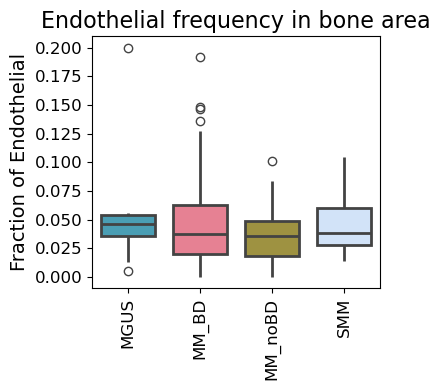

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=df, x='disease2', y='Endothelial', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
plt.xticks(rotation=90)
plt.title(f'Endothelial frequency in bone area', fontsize=16)
plt.ylabel('Fraction of Endothelial', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'EC_fraction_bone.{extension}'), bbox_inches='tight')

In [13]:
MM_BD = df[df['disease2'] == 'MM_BD']['Endothelial']
MM_noBD = df[df['disease2'] == 'MM_noBD']['Endothelial']
stats, p = ttest_ind(MM_BD, MM_noBD)
p

np.float64(0.41561921132351975)

## Same with area

In [51]:
mask = (adata.obs['distance_to_bone_corrected'] <= 20) & (adata.obs['Phenotype4'] == 'Endothelial')
adata_bone_ECs = adata[mask, :].copy()

In [15]:
adata_bone_ECs.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 2782 in TS-373_IMC77_B_001.csv,2782,23,428.739130,781.391304,6.814647,4.346424,0.770197,1.414214,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,1.414214,BONE_VASCULATURE,Endothelial,4.049525,MM
Object 5184 in TS-373_IMC77_B_001.csv,5184,54,799.092593,86.370370,9.548141,7.332141,0.640554,7.280110,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,7.280110,BONE_VASCULATURE,Endothelial,4.059698,MM
Object 5694 in TS-373_IMC77_B_001.csv,5694,92,923.608696,323.956522,17.150134,7.277222,0.905510,8.544004,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,8.544004,BONE_VASCULATURE,Endothelial,4.008603,MM
Object 5710 in TS-373_IMC77_B_001.csv,5710,59,924.237288,311.830508,12.780382,5.907159,0.886773,4.472136,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,4.472136,BONE_VASCULATURE,Endothelial,2.848765,MM
Object 5725 in TS-373_IMC77_B_001.csv,5725,72,928.833333,327.291667,12.157411,7.626898,0.778741,5.000000,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,5.000000,BONE_VASCULATURE,Endothelial,3.711262,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 2275 in TS-373_IMC83_B_001.csv,2275,32,300.750000,843.593750,6.825727,6.104819,0.447301,9.486833,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,9.486833,BONE_ADIPOCYTES,Endothelial,4.985060,MM
Object 5238 in TS-373_IMC83_B_001.csv,5238,133,693.541353,607.902256,14.976830,11.367876,0.651055,16.278821,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,16.278821,BONE_MYELOID,Endothelial,4.508896,MM
Object 5636 in TS-373_IMC83_B_001.csv,5636,92,761.597826,524.336957,14.727085,8.188789,0.831158,19.104973,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,19.104973,BONE_MYELOID,Endothelial,4.585957,MM
Object 5948 in TS-373_IMC83_B_001.csv,5948,86,826.779070,286.511628,13.065764,8.569301,0.754883,12.649111,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,12.649111,BONE_MYELOID,Endothelial,4.165687,MM


In [16]:
adata_bone_ECs.obs.dtypes

Object                           int64
area                             int64
Y_centroid                     float64
X_centroid                     float64
axis_major_length              float64
axis_minor_length              float64
eccentricity                   float64
distance_to_bone               float64
image_ID                      category
disease                       category
patient_ID                    category
ROI                           category
disease2                      category
distance_to_bone_corrected     float64
cellcharter_CN                category
Phenotype4                    category
HistoneH3                      float64
disease3                      category
dtype: object

In [52]:
df = pd.crosstab(adata_bone_ECs.obs['image_ID'], adata_bone_ECs.obs['Phenotype4'],values=adata_bone_ECs.obs['area'], aggfunc='sum')

In [53]:
df['disease2'] = df.index.map(disease_mapping['disease2'])
df['patient_ID'] = df.index.map(patient_mapping['patient_ID'])
df.reset_index(inplace=True)
df

Phenotype4,image_ID,Endothelial,disease2,patient_ID
0,TS-373_IMC01_UB_001.csv,1532,MM_noBD,IMC01
1,TS-373_IMC01_UB_002.csv,853,MM_noBD,IMC01
2,TS-373_IMC02_MGUS_001.csv,30,MGUS,IMC02
3,TS-373_IMC02_MGUS_002.csv,2378,MGUS,IMC02
4,TS-373_IMC03_MGUS_001.csv,273,MGUS,IMC03
...,...,...,...,...
124,TS-373_IMC90.1_B_002.csv,63,MM_BD,IMC90.1
125,TS-373_IMC93_B_001.csv,413,MM_BD,IMC93
126,TS-373_IMC93_B_002.csv,164,MM_BD,IMC93
127,TS-373_IMC95_B_001.csv,503,MM_BD,IMC95


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/4181573293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='disease2', y='Endothelial', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/4181573293.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)


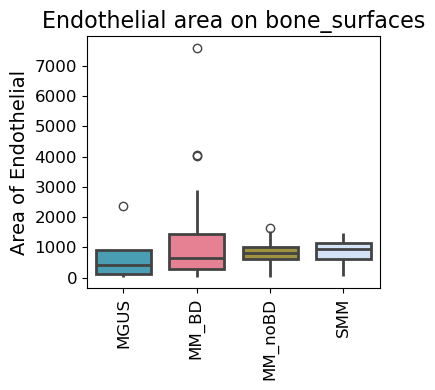

In [54]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=df, x='disease2', y='Endothelial', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
plt.xticks(rotation=90)
plt.title(f'Endothelial area on bone_surfaces', fontsize=16)
plt.ylabel('Area of Endothelial', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'EC_area_bone.{extension}'), bbox_inches='tight')

In [55]:
df['disease2'] = pd.Categorical(
    df['disease2'], categories=['MM_BD', 'MM_noBD', 'SMM', 'MGUS'], ordered=True)
model = smf.mixedlm("Endothelial ~ disease2", data=df, groups=df['patient_ID'])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     Endothelial
No. Observations:       129         Method:                 REML       
No. Groups:             73          Scale:                  857097.1203
Min. group size:        1           Log-Likelihood:         -1043.7274 
Max. group size:        3           Converged:              Yes        
Mean group size:        1.8                                            
-----------------------------------------------------------------------
                      Coef.    Std.Err.   z    P>|z|   [0.025   0.975] 
-----------------------------------------------------------------------
Intercept              987.321  104.705  9.430 0.000   782.103 1192.540
disease2[T.MM_noBD]   -144.968  291.278 -0.498 0.619  -715.862  425.926
disease2[T.SMM]       -125.911  345.473 -0.364 0.716  -803.025  551.202
disease2[T.MGUS]      -312.586  357.870 -0.873 0.382 -1013.998  388.827
Group Var

In [20]:
MM_BD = df[df['disease2'] == 'MM_BD']['Endothelial']
MM_noBD = df[df['disease2'] == 'MM_noBD']['Endothelial']
stats, p = ttest_ind(MM_BD, MM_noBD)
p

np.float64(0.6176966717212711)

# Combine bone surface and EC area together

In [56]:
df = df.set_index('image_ID')
df

Phenotype4,Endothelial,disease2,patient_ID
image_ID,,,
TS-373_IMC01_UB_001.csv,1532,MM_noBD,IMC01
TS-373_IMC01_UB_002.csv,853,MM_noBD,IMC01
TS-373_IMC02_MGUS_001.csv,30,MGUS,IMC02
TS-373_IMC02_MGUS_002.csv,2378,MGUS,IMC02
TS-373_IMC03_MGUS_001.csv,273,MGUS,IMC03
...,...,...,...
TS-373_IMC90.1_B_002.csv,63,MM_BD,IMC90.1
TS-373_IMC93_B_001.csv,413,MM_BD,IMC93
TS-373_IMC93_B_002.csv,164,MM_BD,IMC93


In [22]:
df_bone_area

,bone_area,disease2
TS-373_IMC77_B_001.csv,68621.50,MM_BD
TS-373_IMC03_MGUS_002.csv,217837.75,MGUS
TS-373_IMC04_MGUS_002.csv,72397.25,MGUS
TS-373_IMC72_MGUS_001.csv,0.00,MGUS
TS-373_IMC12_UB_001.csv,236137.00,MM_noBD
...,...,...
TS-373_IMC41_MGUS_001.csv,0.00,SMM
TS-373_IMC87-1_UB_001.csv,0.00,MM_noBD
TS-373_IMC53_B_002.csv,38168.50,MM_BD
TS-373_IMC47_B_002.csv,140392.25,MM_BD


In [57]:
df_merged = df.merge(df_bone_area, left_index=True, right_index=True)
df_merged

,Endothelial,disease2_x,patient_ID_x,bone_area,disease2_y,patient_ID_y
TS-373_IMC01_UB_001.csv,1532,MM_noBD,IMC01,194110.50,MM_noBD,IMC01
TS-373_IMC01_UB_002.csv,853,MM_noBD,IMC01,125435.75,MM_noBD,IMC01
TS-373_IMC02_MGUS_001.csv,30,MGUS,IMC02,8558.50,MGUS,IMC02
TS-373_IMC02_MGUS_002.csv,2378,MGUS,IMC02,321878.75,MGUS,IMC02
TS-373_IMC03_MGUS_001.csv,273,MGUS,IMC03,147471.75,MGUS,IMC03
...,...,...,...,...,...,...
TS-373_IMC90.1_B_002.csv,63,MM_BD,IMC90.1,172386.50,MM_BD,IMC90.1
TS-373_IMC93_B_001.csv,413,MM_BD,IMC93,125131.25,MM_BD,IMC93
TS-373_IMC93_B_002.csv,164,MM_BD,IMC93,83334.00,MM_BD,IMC93
TS-373_IMC95_B_001.csv,503,MM_BD,IMC95,287254.00,MM_BD,IMC95


In [58]:
df_merged['EC_to_bone_area'] = df_merged['Endothelial'] / df_merged['bone_area']
df_merged

,Endothelial,disease2_x,patient_ID_x,bone_area,disease2_y,patient_ID_y,EC_to_bone_area
TS-373_IMC01_UB_001.csv,1532,MM_noBD,IMC01,194110.50,MM_noBD,IMC01,0.007892
TS-373_IMC01_UB_002.csv,853,MM_noBD,IMC01,125435.75,MM_noBD,IMC01,0.006800
TS-373_IMC02_MGUS_001.csv,30,MGUS,IMC02,8558.50,MGUS,IMC02,0.003505
TS-373_IMC02_MGUS_002.csv,2378,MGUS,IMC02,321878.75,MGUS,IMC02,0.007388
TS-373_IMC03_MGUS_001.csv,273,MGUS,IMC03,147471.75,MGUS,IMC03,0.001851
...,...,...,...,...,...,...,...
TS-373_IMC90.1_B_002.csv,63,MM_BD,IMC90.1,172386.50,MM_BD,IMC90.1,0.000365
TS-373_IMC93_B_001.csv,413,MM_BD,IMC93,125131.25,MM_BD,IMC93,0.003301
TS-373_IMC93_B_002.csv,164,MM_BD,IMC93,83334.00,MM_BD,IMC93,0.001968
TS-373_IMC95_B_001.csv,503,MM_BD,IMC95,287254.00,MM_BD,IMC95,0.001751


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/1738210373.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='disease2_x', y='EC_to_bone_area', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_7376/1738210373.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)


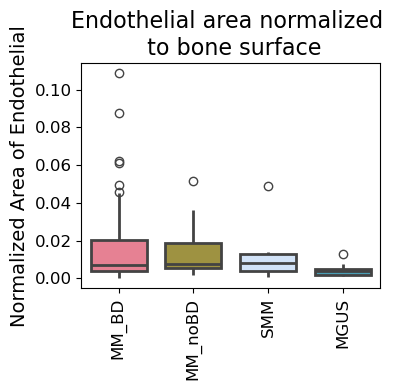

In [59]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=df_merged, x='disease2_x', y='EC_to_bone_area', palette=disease_color_map, ax=ax, showcaps=False, linewidth=2, width=0.75)
plt.xticks(rotation=90)
plt.title(f'Endothelial area normalized \n to bone surface', fontsize=16)
plt.ylabel('Normalized Area of Endothelial', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'EC_area_to_bone_area.{extension}'), bbox_inches='tight')

In [60]:
df_merged['disease2_x'] = pd.Categorical(
    df_merged['disease2_x'], categories=['MM_BD', 'MM_noBD', 'SMM', 'MGUS'], ordered=True)
model = smf.mixedlm("EC_to_bone_area ~ disease2_x", data=df_merged, groups=df_merged['patient_ID_x'])
result = model.fit()
print(result.summary())

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  EC_to_bone_area
No. Observations:  129      Method:              REML           
No. Groups:        73       Scale:               0.0002         
Min. group size:   1        Log-Likelihood:      324.8236       
Max. group size:   3        Converged:           Yes            
Mean group size:   1.8                                          
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.015    0.002  7.733 0.000  0.011  0.019
disease2_x[T.MM_noBD] -0.000    0.005 -0.013 0.990 -0.011  0.010
disease2_x[T.SMM]     -0.003    0.006 -0.515 0.607 -0.016  0.009
disease2_x[T.MGUS]    -0.010    0.007 -1.568 0.117 -0.023  0.003
Group Var              0.000    0.003                           



/Users/lukashat/miniforge3/envs/spatial_plotting/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [26]:
df_merged

,Endothelial,disease2_x,bone_area,disease2_y,EC_to_bone_area
TS-373_IMC01_UB_001.csv,1532,MM_noBD,194110.50,MM_noBD,0.007892
TS-373_IMC01_UB_002.csv,853,MM_noBD,125435.75,MM_noBD,0.006800
TS-373_IMC02_MGUS_001.csv,30,MGUS,8558.50,MGUS,0.003505
TS-373_IMC02_MGUS_002.csv,2378,MGUS,321878.75,MGUS,0.007388
TS-373_IMC03_MGUS_001.csv,273,MGUS,147471.75,MGUS,0.001851
...,...,...,...,...,...
TS-373_IMC90.1_B_002.csv,63,MM_BD,172386.50,MM_BD,0.000365
TS-373_IMC93_B_001.csv,413,MM_BD,125131.25,MM_BD,0.003301
TS-373_IMC93_B_002.csv,164,MM_BD,83334.00,MM_BD,0.001968
TS-373_IMC95_B_001.csv,503,MM_BD,287254.00,MM_BD,0.001751


In [27]:
df_merged.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/Revision/EC_area_to_bone_area.csv')